In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
train_data = pd.read_csv('/Users/sana/Downloads/habitawise_dataset/train (1).csv')
test_data = pd.read_csv('/Users/sana/Downloads/habitawise_dataset/test (1).csv')

In [12]:
test_data.head(5)

,Id,Property_Type,Property_Area,Number_of_Windows,Number_of_Doors,Furnishing,Frequency_of_Powercuts,Power_Backup,Water_Supply,Traffic_Density_Score,Crime_Rate,Dust_and_Noise,Air_Quality_Index,Neighborhood_Review
0,0x6808,Single-family home,1521,5.0,1,Unfurnished,0.0,No,All time,7.61,Well below average,Medium,156.0,4.71
1,0x6a98,Single-family home,2233,2.0,1,Semi_Furnished,0.0,No,Once in a day - Morning,5.28,Well below average,Medium,82.0,4.50
2,0xacc0,Apartment,986,1.0,1,Unfurnished,0.0,No,All time,7.72,Well below average,Medium,91.0,4.79
3,0x8225,Single-family home,1625,2.0,1,Semi_Furnished,0.0,No,Once in a day - Evening,6.19,Well below average,Medium,159.0,4.09
4,0xaee8,Single-family home,1166,2.0,2,Fully Furnished,0.0,No,Once in a day - Evening,5.84,Slightly below average,Medium,82.0,3.56


In [13]:
train_data.head(5)

,Id,Property_Type,Property_Area,Number_of_Windows,Number_of_Doors,Furnishing,Frequency_of_Powercuts,Power_Backup,Water_Supply,Traffic_Density_Score,Crime_Rate,Dust_and_Noise,Air_Quality_Index,Neighborhood_Review,Habitability_score
0,0x21e3,Apartment,106,NaN,1,Semi_Furnished,0.0,No,Once in a day - Morning,5.89,Slightly below average,Medium,90,3.86,71.98
1,0x68d4,Apartment,733,2.0,2,Unfurnished,1.0,No,Once in a day - Evening,4.37,Well below average,Medium,96,3.55,71.20
2,0x7d81,Apartment,737,4.0,2,Fully Furnished,0.0,No,Once in a day - Morning,7.45,Slightly below average,Medium,121,3.81,71.39
3,0x7a57,Apartment,900,3.0,2,Unfurnished,2.0,Yes,Once in a day - Morning,6.16,Well above average,Medium,100,1.34,31.46
4,0x9409,Bungalow,2238,14.0,6,Fully Furnished,0.0,No,All time,5.46,Well below average,Medium,116,4.77,93.70


In [24]:
print(train_data.shape)
print(test_data.shape)

(31599, 14)
(7900, 14)


In [16]:
train_data.shape[1], train_data.columns

(15,
 Index(['Id', 'Property_Type', 'Property_Area', 'Number_of_Windows',
        'Number_of_Doors', 'Furnishing', 'Frequency_of_Powercuts',
        'Power_Backup', 'Water_Supply', 'Traffic_Density_Score', 'Crime_Rate',
        'Dust_and_Noise', 'Air_Quality_Index', 'Neighborhood_Review',
        'Habitability_score'],
       dtype='object'))

In [17]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31599 entries, 0 to 31598
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      31599 non-null  object 
 1   Property_Type           31599 non-null  object 
 2   Property_Area           31599 non-null  int64  
 3   Number_of_Windows       30266 non-null  float64
 4   Number_of_Doors         31599 non-null  int64  
 5   Furnishing              30771 non-null  object 
 6   Frequency_of_Powercuts  30490 non-null  float64
 7   Power_Backup            31599 non-null  object 
 8   Water_Supply            31599 non-null  object 
 9   Traffic_Density_Score   31599 non-null  float64
 10  Crime_Rate              30970 non-null  object 
 11  Dust_and_Noise          30600 non-null  object 
 12  Air_Quality_Index       31599 non-null  int64  
 13  Neighborhood_Review     31599 non-null  float64
 14  Habitability_score      31599 non-null

In [18]:
train_data.drop(columns = "Id", inplace=True)

In [25]:
train_data.isnull().sum()/train_data.shape[0]*100

Property_Type             0.000000
Property_Area             0.000000
Number_of_Windows         4.218488
Number_of_Doors           0.000000
Furnishing                2.620336
Frequency_of_Powercuts    3.509605
Power_Backup              0.000000
Water_Supply              0.000000
Traffic_Density_Score     0.000000
Crime_Rate                1.990569
Dust_and_Noise            3.161492
Air_Quality_Index         0.000000
Neighborhood_Review       0.000000
Habitability_score        0.000000
dtype: float64

In [26]:
print(train_data.isnull().sum())
print(test_data.isnull().sum())


Property_Type                0
Property_Area                0
Number_of_Windows         1333
Number_of_Doors              0
Furnishing                 828
Frequency_of_Powercuts    1109
Power_Backup                 0
Water_Supply                 0
Traffic_Density_Score        0
Crime_Rate                 629
Dust_and_Noise             999
Air_Quality_Index            0
Neighborhood_Review          0
Habitability_score           0
dtype: int64
Id                          0
Property_Type               0
Property_Area               0
Number_of_Windows         321
Number_of_Doors             0
Furnishing                214
Frequency_of_Powercuts    274
Power_Backup                0
Water_Supply                0
Traffic_Density_Score       0
Crime_Rate                158
Dust_and_Noise            220
Air_Quality_Index           0
Neighborhood_Review         0
dtype: int64


In [30]:
categorical = train_data.select_dtypes(include =[object])
print(categorical.columns)


numerical= train_data.select_dtypes(include =[np.float64,np.int64])
print(numerical.columns)

Index(['Property_Type', 'Furnishing', 'Power_Backup', 'Water_Supply',
       'Crime_Rate', 'Dust_and_Noise'],
      dtype='object')
Index(['Property_Area', 'Number_of_Windows', 'Number_of_Doors',
       'Frequency_of_Powercuts', 'Traffic_Density_Score', 'Air_Quality_Index',
       'Neighborhood_Review', 'Habitability_score'],
      dtype='object')


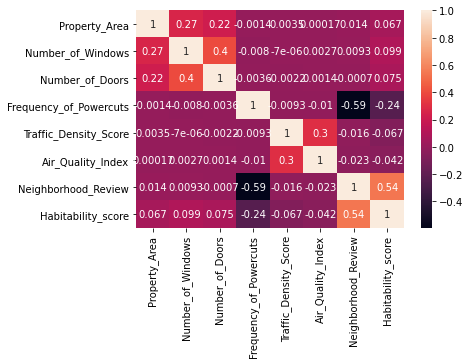

In [23]:
corr_mat = train_data.corr(numeric_only=True)
sns.heatmap(corr_mat, annot=True)
plt.show()

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

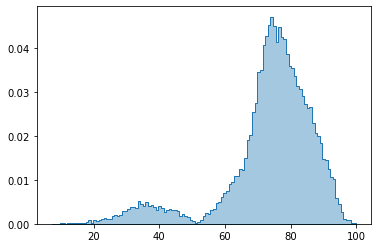

In [21]:
sns.histplot(train_data["Habitability_score"], kde=True, stat="density", 
             alpha=0.4, element="step", label="Habitability_score")

mean = train_data["Habitability_score"].mean()
std_dev = train_data["Habitability_score"].std()
x = np.linspace(mean - 3 * std_dev, mean + 3 * std_dev, 1000)
y = norm. train_data(x, mean, std_dev)

plt.plot(x, y, 'r', linewidth=2,label='Gaussian Curve')

plt.legend()
plt.tight_layout()
plt.show()

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=numerical)
plt.title('Box plot of numerical data')
plt.xlabel('Features')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.show()

AttributeError: 'DataFrame' object has no attribute 'iteritems'

<Figure size 720x432 with 0 Axes>